In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import LocalOutlierFactor

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df = pd.read_csv('creditcard.csv')

In [27]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


# Problem Understanding



---


**Q. What is Fraud detection?**

Fraud detection means analyzing transactions or behaviors to find activities that are dishonest or abnormal.

**Q. Why is it difficult?**

Fraud detection is difficult because of highly imbalanced data,evolving fraud patterns,limited labeled data,high false positives,and need for real time detection

**Q. Why use unsupervised learning?**

Unsupervised learning is used for fraud detection because fraud transactions
are extremely rare and labels may be incomplete or unreliable. These methods detect anomalies by identifying transactions that deviate from normal behavior.


---



# Exploratory Data Analysis


---



In [28]:
df.shape

(284807, 31)

In [29]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Class
0    284315
1       492
Name: count, dtype: int64


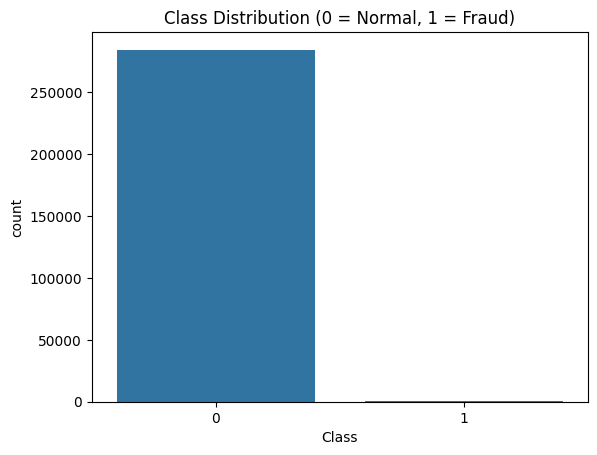

In [12]:
# Class Imbalance Observation
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

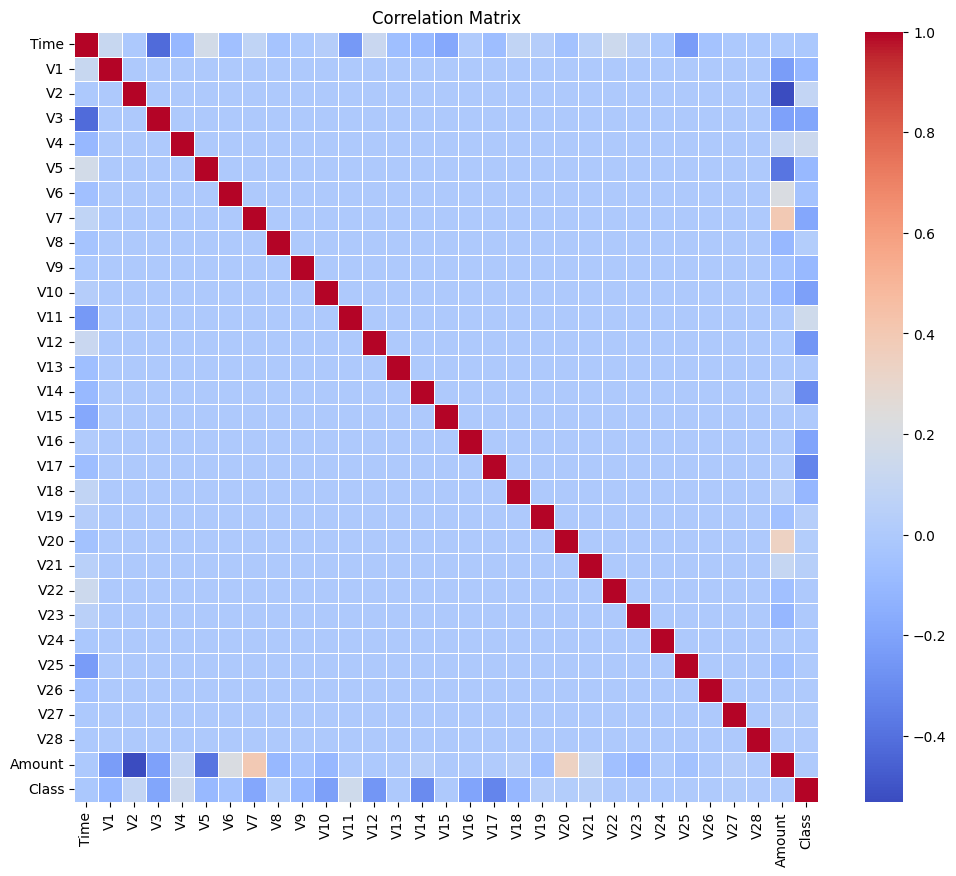

In [13]:
plt.figure(figsize=(12,10))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

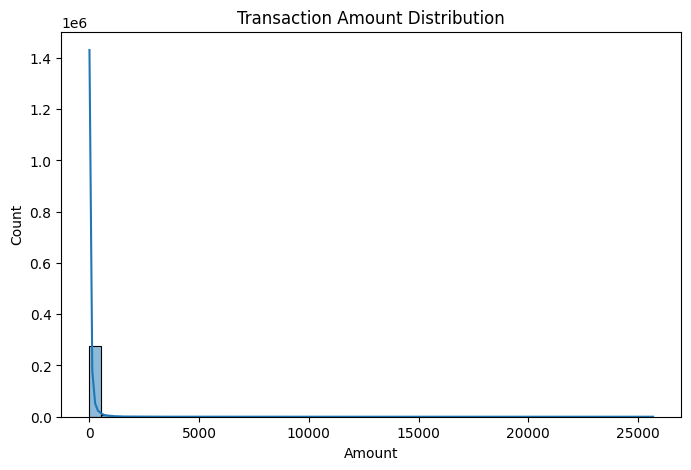

In [17]:
#Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

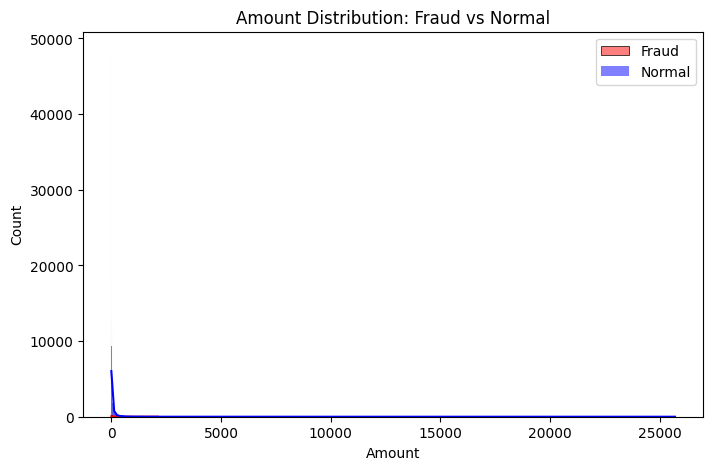

In [18]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

plt.figure(figsize=(8,5))
sns.histplot(fraud['Amount'], color='red', label='Fraud', kde=True)
sns.histplot(normal['Amount'], color='blue', label='Normal', kde=True)
plt.legend()
plt.title("Amount Distribution: Fraud vs Normal")
plt.show()

# Insights

Severe Class Imbalance


Fraud cases are extremely rare (~0.17%)


Most transactions are small


Fraud often occurs in specific ranges


Some anonymized features (V1–V28) show different patterns for fraud


No Missing Values
Dataset is clean


Certain features are strongly related to fraud class


---



# Data Preprocessing


---



In [30]:
#  FEATURE SCALING
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
#Feature Seelction

In [31]:
corr = df.corr()

target_corr = corr['Class'].abs().sort_values(ascending=False)

print(target_corr.head(15))


Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
V1       0.101347
V9       0.097733
V5       0.094974
V2       0.091289
Name: Class, dtype: float64


In [23]:
selected_features = target_corr[1:15].index
print(selected_features)

Index(['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1',
       'V9', 'V5', 'V2'],
      dtype='object')


Based on correlation analysis, the top features with highest absolute correlation to the target variable were selected.
We selected the top 10–15 features to balance between model performance and complexity.
Highly correlated features like V17, V14, and V12 were prioritized as they contribute more significantly to fraud detection.


---



Clustering model (K means)


---



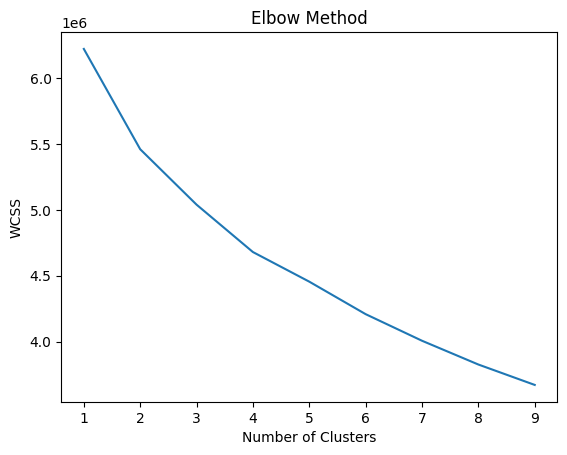

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

X = df[selected_features]
y = df['Class']

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [34]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

In [35]:
print(pd.crosstab(df['Cluster'], df['Class']))

Class         0    1
Cluster             
0        134936  136
1        149379  356


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

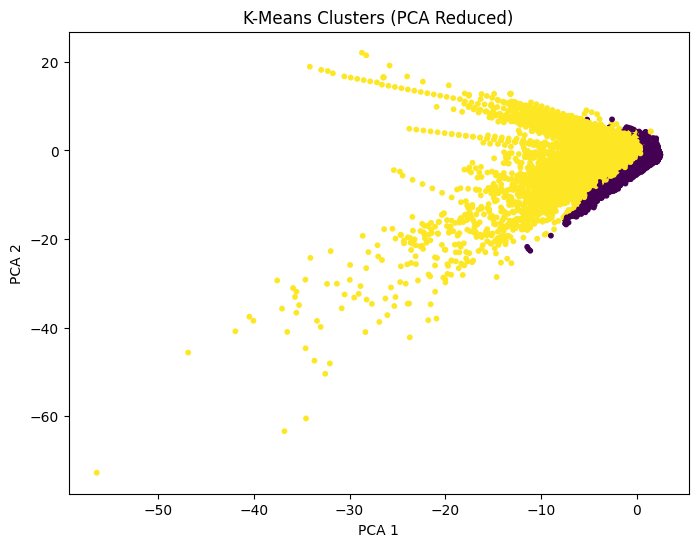

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', s=10)

plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()



---



# Anomaly Detection Model (Isolation Forest)


---



In [39]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.001,
    random_state=42
)

df['Anomaly'] = iso.fit_predict(X)

In [40]:
df['Anomaly'] = df['Anomaly'].map({1:0, -1:1})

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, df['Anomaly']))
print(classification_report(y, df['Anomaly']))

[[284210    105]
 [   312    180]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.63      0.37      0.46       492

    accuracy                           1.00    284807
   macro avg       0.82      0.68      0.73    284807
weighted avg       1.00      1.00      1.00    284807





---



# Comparison of methods


---



In [42]:
# KMeans as anomaly (assume smaller cluster = fraud)
cluster_counts = df['Cluster'].value_counts()
fraud_cluster = cluster_counts.idxmin()

df['KMeans_Anomaly'] = df['Cluster'].apply(lambda x: 1 if x == fraud_cluster else 0)

print("KMeans Evaluation:")
print(classification_report(y, df['KMeans_Anomaly']))

print("Isolation Forest Evaluation:")
print(classification_report(y, df['Anomaly']))

KMeans Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.53      0.69    284315
           1       0.00      0.28      0.00       492

    accuracy                           0.52    284807
   macro avg       0.50      0.40      0.35    284807
weighted avg       1.00      0.52      0.69    284807

Isolation Forest Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.63      0.37      0.46       492

    accuracy                           1.00    284807
   macro avg       0.82      0.68      0.73    284807
weighted avg       1.00      1.00      1.00    284807





---



**Which model is better for fraud detection? Why?**

Isolation Forest performed better than K-Means for fraud detection.


**K-Means**


Groups data into clusters


Assumes data is evenly distributed


Struggles with rare cases (fraud)


**Isolation Forest**


Specifically designed for anomaly detection


Works well with rare and unusual data points


Does not assume normal distribution


Isolates fraud cases more effectively

# Business Perspective Summary
In real-world financial systems, fraudulent transactions are extremely rare but highly impactful.
Detecting fraud accurately is critical to prevent financial losses and maintain customer trust.
Traditional clustering methods like K-Means may fail to identify such rare events effectively.
Anomaly detection models like Isolation Forest are more practical because they focus on identifying unusual behavior rather than grouping normal transactions.

# Recommendation
Based on the analysis, it is recommended to use Isolation Forest for fraud detection systems.
It provides better detection of rare anomalies and can adapt to large-scale financial datasets.
However, K-Means can still be used as a supporting method for understanding transaction patterns and grouping similar behaviors.
For production systems, combining anomaly detection with continuous monitoring and periodic model updates would further improve performance.